# Customer Segmentation

## Importing of libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-pastel')

## Importing of data

In [2]:
data=pd.read_csv(r"C:\Users\Rano's PC\Machine\github_repo_cloned\Elevvo_Internship\Task-9\customer_data.csv")

In [3]:
pd.set_option("display.max_columns",None)

In [4]:
data.head()

,customer_id,cancel_rate,first_purchase,customer_city,customer_state,customer_zip,total_orders,total_order_price,avg_order_price,total_freight_value,avg_freight_value,fav_payment_mode,median_product_weight,fav_seller_id,seller_city,seller_state,fav_product_category,fav_purchase_time,avg_delivery_days,payemnt_installments,sequential_payment,avg_review_score
0,0000366f3b9a7992bf8c76cfdf3221e2,0.0,2018-05-10,cajamar,SP,7787,1,129.90,129.90,12.00,12.00,credit_card,1500.0,da8622b14eb17ae2831f4ac5b9dab84a,piracicaba,SP,bed_bath_table,morning,6.0,1,0,5.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,0.0,2018-05-07,osasco,SP,6053,1,18.90,18.90,8.29,8.29,credit_card,375.0,138dbe45fc62f1e244378131a6801526,sao paulo,SP,health_beauty,morning,3.0,0,0,4.0
2,0000f46a3911fa3c0805444483337064,0.0,2017-03-10,sao jose,SC,88115,1,69.00,69.00,17.22,17.22,credit_card,1500.0,3d871de0142ce09b7081e2b9d1733cb1,campo limpo paulista,SP,stationery,night,26.0,1,0,3.0
3,0000f6ccb0745a6a4b88665a16c9f078,0.0,2017-10-12,belem,PA,66812,1,25.99,25.99,17.63,17.63,credit_card,150.0,ef506c96320abeedfb894c34db06f478,sao paulo,SP,telephony,night,20.0,1,0,4.0
4,0004aac84e0df4da2b147fca70cf8255,0.0,2017-11-14,sorocaba,SP,18040,1,180.00,180.00,16.89,16.89,credit_card,6050.0,70a12e78e608ac31179aea7f8422044b,jacarei,SP,telephony,evening,13.0,1,0,5.0


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96096 entries, 0 to 96095
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            96096 non-null  object 
 1   cancel_rate            96096 non-null  float64
 2   first_purchase         96096 non-null  object 
 3   customer_city          96096 non-null  object 
 4   customer_state         96096 non-null  object 
 5   customer_zip           96096 non-null  int64  
 6   total_orders           96096 non-null  int64  
 7   total_order_price      96096 non-null  float64
 8   avg_order_price        95420 non-null  float64
 9   total_freight_value    96096 non-null  float64
 10  avg_freight_value      95420 non-null  float64
 11  fav_payment_mode       96095 non-null  object 
 12  median_product_weight  95407 non-null  float64
 13  fav_seller_id          95420 non-null  object 
 14  seller_city            95420 non-null  object 
 15  se

## Some data cleaning

In [6]:
data['first_purchase']=pd.to_datetime(data['first_purchase'])

In [7]:
data['customer_zip']=data['customer_zip'].astype('str')

In [8]:
data.head()

,customer_id,cancel_rate,first_purchase,customer_city,customer_state,customer_zip,total_orders,total_order_price,avg_order_price,total_freight_value,avg_freight_value,fav_payment_mode,median_product_weight,fav_seller_id,seller_city,seller_state,fav_product_category,fav_purchase_time,avg_delivery_days,payemnt_installments,sequential_payment,avg_review_score
0,0000366f3b9a7992bf8c76cfdf3221e2,0.0,2018-05-10,cajamar,SP,7787,1,129.90,129.90,12.00,12.00,credit_card,1500.0,da8622b14eb17ae2831f4ac5b9dab84a,piracicaba,SP,bed_bath_table,morning,6.0,1,0,5.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,0.0,2018-05-07,osasco,SP,6053,1,18.90,18.90,8.29,8.29,credit_card,375.0,138dbe45fc62f1e244378131a6801526,sao paulo,SP,health_beauty,morning,3.0,0,0,4.0
2,0000f46a3911fa3c0805444483337064,0.0,2017-03-10,sao jose,SC,88115,1,69.00,69.00,17.22,17.22,credit_card,1500.0,3d871de0142ce09b7081e2b9d1733cb1,campo limpo paulista,SP,stationery,night,26.0,1,0,3.0
3,0000f6ccb0745a6a4b88665a16c9f078,0.0,2017-10-12,belem,PA,66812,1,25.99,25.99,17.63,17.63,credit_card,150.0,ef506c96320abeedfb894c34db06f478,sao paulo,SP,telephony,night,20.0,1,0,4.0
4,0004aac84e0df4da2b147fca70cf8255,0.0,2017-11-14,sorocaba,SP,18040,1,180.00,180.00,16.89,16.89,credit_card,6050.0,70a12e78e608ac31179aea7f8422044b,jacarei,SP,telephony,evening,13.0,1,0,5.0


In [9]:
data[data['total_orders']!=1]

,customer_id,cancel_rate,first_purchase,customer_city,customer_state,customer_zip,total_orders,total_order_price,avg_order_price,total_freight_value,avg_freight_value,fav_payment_mode,median_product_weight,fav_seller_id,seller_city,seller_state,fav_product_category,fav_purchase_time,avg_delivery_days,payemnt_installments,sequential_payment,avg_review_score
106,004288347e5e88a27ded2bb23747066c,0.0,2017-07-27,nova iguacu,RJ,26220,2,317.89,158.945000,36.48,18.240000,credit_card,1162.5,6cd68b3ed6d59aaa9fece558ad360c0a,belo horizonte,MG,cool_stuff,afternoon,6.5,1,0,5.000000
123,004ad212c650c96c8a48f30855a7bcb8,0.0,2017-09-24,ataleia,MG,39850,0,0.00,NaN,0.00,NaN,credit_card,NaN,NaN,NaN,NaN,NaN,morning,NaN,0,0,1.000000
124,004b45ec5c64187465168251cd1c9c2f,0.0,2017-09-01,maceio,AL,57055,2,86.90,43.450000,60.82,30.410000,boleto,2650.0,1025f0e2d44d7041d6cf58b6550e0bfa,sao jose do rio preto,SP,furniture_decor,afternoon,24.0,0,0,3.000000
144,0058f300f57d7b93c477a131a59b36c3,0.5,2018-02-19,salvador,BA,40731,2,132.48,66.240000,43.10,21.550000,voucher,600.0,dbc22125167c298ef99da25668e1011f,borda da mata,MG,luggage_accessories,evening,13.0,0,1,3.000000
177,0071f46a072a9ae25bbe4438b15efe9c,0.0,2017-02-01,aracatuba,SP,16011,0,0.00,NaN,0.00,NaN,credit_card,NaN,NaN,NaN,NaN,NaN,midnight,NaN,1,0,3.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95810,ff44401d0d8f5b9c54a47374eb48c1b8,0.0,2017-05-19,campinas,SP,13070,2,39.80,19.900000,28.20,14.100000,voucher,175.0,0ea22c1cfbdc755f86b9b54b39c16043,sete lagoas,MG,fashion_bags_accessories,night,12.5,0,1,3.000000
95916,ff8892f7c26aa0446da53d01b18df463,0.0,2017-05-24,ibiraja,BA,45972,2,277.95,138.975000,52.19,26.095000,credit_card,375.0,391fc6631aebcf3004804e51b40bcf1e,colombo,PR,bed_bath_table,evening,37.0,1,0,2.666667
95934,ff922bdd6bafcdf99cb90d7f39cea5b3,0.0,2017-02-22,barra bonita,SP,17340,3,94.79,31.596667,44.81,14.936667,credit_card,350.0,0ea22c1cfbdc755f86b9b54b39c16043,curitiba,SP,bed_bath_table,afternoon,17.0,1,0,4.333333
95988,ffb5431b49b42c9f3209f087e1bfdcfa,0.0,2018-02-09,rio de janeiro,RJ,20270,0,0.00,NaN,0.00,NaN,credit_card,NaN,NaN,NaN,NaN,NaN,evening,NaN,0,0,1.000000


In [10]:
data.drop(columns=['avg_order_price','avg_freight_value'],inplace=True)

In [11]:
data.head()

,customer_id,cancel_rate,first_purchase,customer_city,customer_state,customer_zip,total_orders,total_order_price,total_freight_value,fav_payment_mode,median_product_weight,fav_seller_id,seller_city,seller_state,fav_product_category,fav_purchase_time,avg_delivery_days,payemnt_installments,sequential_payment,avg_review_score
0,0000366f3b9a7992bf8c76cfdf3221e2,0.0,2018-05-10,cajamar,SP,7787,1,129.90,12.00,credit_card,1500.0,da8622b14eb17ae2831f4ac5b9dab84a,piracicaba,SP,bed_bath_table,morning,6.0,1,0,5.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,0.0,2018-05-07,osasco,SP,6053,1,18.90,8.29,credit_card,375.0,138dbe45fc62f1e244378131a6801526,sao paulo,SP,health_beauty,morning,3.0,0,0,4.0
2,0000f46a3911fa3c0805444483337064,0.0,2017-03-10,sao jose,SC,88115,1,69.00,17.22,credit_card,1500.0,3d871de0142ce09b7081e2b9d1733cb1,campo limpo paulista,SP,stationery,night,26.0,1,0,3.0
3,0000f6ccb0745a6a4b88665a16c9f078,0.0,2017-10-12,belem,PA,66812,1,25.99,17.63,credit_card,150.0,ef506c96320abeedfb894c34db06f478,sao paulo,SP,telephony,night,20.0,1,0,4.0
4,0004aac84e0df4da2b147fca70cf8255,0.0,2017-11-14,sorocaba,SP,18040,1,180.00,16.89,credit_card,6050.0,70a12e78e608ac31179aea7f8422044b,jacarei,SP,telephony,evening,13.0,1,0,5.0


In [12]:
data['fav_payment_mode'].value_counts()

fav_payment_mode
credit_card    72701
boleto         19273
voucher         2653
debit_card      1466
not_defined        2
Name: count, dtype: int64

In [13]:
data['customer_city'].nunique()

4118

In [14]:
data['seller_city'].nunique()

608

In [15]:
data.columns

Index(['customer_id', 'cancel_rate', 'first_purchase', 'customer_city',
       'customer_state', 'customer_zip', 'total_orders', 'total_order_price',
       'total_freight_value', 'fav_payment_mode', 'median_product_weight',
       'fav_seller_id', 'seller_city', 'seller_state', 'fav_product_category',
       'fav_purchase_time', 'avg_delivery_days', 'payemnt_installments',
       'sequential_payment', 'avg_review_score'],
      dtype='object')

In [16]:
data.isnull().sum()

customer_id                 0
cancel_rate                 0
first_purchase              0
customer_city               0
customer_state              0
customer_zip                0
total_orders                0
total_order_price           0
total_freight_value         0
fav_payment_mode            1
median_product_weight     689
fav_seller_id             676
seller_city               676
seller_state              676
fav_product_category     2036
fav_purchase_time           0
avg_delivery_days        2740
payemnt_installments        0
sequential_payment          0
avg_review_score          716
dtype: int64

In [17]:
data['fav_payment_mode']=data['fav_payment_mode'].fillna(data['fav_payment_mode'].mode()[0])

In [18]:
data['median_product_weight'].fillna(0,inplace=True)

In [19]:
columns=['fav_seller_id', 'seller_city', 'seller_state','fav_product_category']
for value in columns:
    data[value].fillna('undefined',inplace=True)

In [20]:
num_cols=['avg_delivery_days','avg_review_score']
for value in num_cols:
    data[value].fillna(0,inplace=True)

In [21]:
data.isnull().sum()

customer_id              0
cancel_rate              0
first_purchase           0
customer_city            0
customer_state           0
customer_zip             0
total_orders             0
total_order_price        0
total_freight_value      0
fav_payment_mode         0
median_product_weight    0
fav_seller_id            0
seller_city              0
seller_state             0
fav_product_category     0
fav_purchase_time        0
avg_delivery_days        0
payemnt_installments     0
sequential_payment       0
avg_review_score         0
dtype: int64

## Segmentation

In [22]:
X=data.drop(columns=['customer_id','customer_city','seller_city','customer_zip','first_purchase'])

In [23]:
X.head(1)

,cancel_rate,customer_state,total_orders,total_order_price,total_freight_value,fav_payment_mode,median_product_weight,fav_seller_id,seller_state,fav_product_category,fav_purchase_time,avg_delivery_days,payemnt_installments,sequential_payment,avg_review_score
0,0.0,SP,1,129.9,12.0,credit_card,1500.0,da8622b14eb17ae2831f4ac5b9dab84a,SP,bed_bath_table,morning,6.0,1,0,5.0


In [24]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import silhouette_score

In [25]:
#Defining the preprocessor
processor=ColumnTransformer(transformers=[
    ('ohe',OneHotEncoder(sparse_output=False,drop='first',handle_unknown='ignore'),[1,5,7,8,9,10]),
    ('scaling',StandardScaler(),[0,2,3,4,6,11,12,13,14])
],remainder='passthrough')

In [26]:
X_processed=processor.fit_transform(X)

In [27]:
# scores = []
# for k in range(6, 15):
#     model = KMeans(n_clusters=k, random_state=42)
#     model.fit(X_processed)
#     scores.append(model.inertia_)
# print(scores)

In [30]:
# plt.plot(range(6,15), scores, marker='o')
# plt.title("WCSS vs K")
# plt.xlabel("No. of Clusters")
# plt.ylabel("Silhouette Score")
# plt.show()

In [37]:
# Applying values to the k means model
k = 10 
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X_processed)
X['class'] = clusters

In [38]:
# Using PCA to plot my clusters, changin it to a 3D model
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
pca_data=pca.fit_transform(X_processed)
pca_data = pd.DataFrame(data=pca_data, columns=['PC1', 'PC2'])
pca_data['class'] = X['class'].values

In [39]:
X.head()

,cancel_rate,customer_state,total_orders,total_order_price,total_freight_value,fav_payment_mode,median_product_weight,fav_seller_id,seller_state,fav_product_category,fav_purchase_time,avg_delivery_days,payemnt_installments,sequential_payment,avg_review_score,class
0,0.0,SP,1,129.90,12.00,credit_card,1500.0,da8622b14eb17ae2831f4ac5b9dab84a,SP,bed_bath_table,morning,6.0,1,0,5.0,3
1,0.0,SP,1,18.90,8.29,credit_card,375.0,138dbe45fc62f1e244378131a6801526,SP,health_beauty,morning,3.0,0,0,4.0,7
2,0.0,SC,1,69.00,17.22,credit_card,1500.0,3d871de0142ce09b7081e2b9d1733cb1,SP,stationery,night,26.0,1,0,3.0,1
3,0.0,PA,1,25.99,17.63,credit_card,150.0,ef506c96320abeedfb894c34db06f478,SP,telephony,night,20.0,1,0,4.0,3
4,0.0,SP,1,180.00,16.89,credit_card,6050.0,70a12e78e608ac31179aea7f8422044b,SP,telephony,evening,13.0,1,0,5.0,3


In [40]:
import plotly.express as px

# ----------------------------
# 1. Prepare Your Data
# ----------------------------
# Assume df is your DataFrame and 'segment' is the label column
y = X['class']
x = X.drop(columns=['class'])  # Remove the segment column
                 # Store the labels separately

# Standardize the data
X_scaled = processor.fit_transform(x)

# ----------------------------
# 2. Apply PCA (3 Components)
# ----------------------------
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# Combine PCA results with segment for plotting
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2', 'PC3'])
pca_df['segment'] = y.values

# ----------------------------
# 3. Plot Using Plotly
# ----------------------------
fig = px.scatter_3d(
    pca_df,
    x='PC1',
    y='PC2',
    z='PC3',
    color='segment',
    title='3D PCA Scatter Plot (Interactive)',
    labels={'PC1': 'Principal Component 1', 'PC2': 'Principal Component 2', 'PC3': 'Principal Component 3'},
    opacity=0.7,
    width=900,
    height=600
)

fig.show()

In [41]:
X

,cancel_rate,customer_state,total_orders,total_order_price,total_freight_value,fav_payment_mode,median_product_weight,fav_seller_id,seller_state,fav_product_category,fav_purchase_time,avg_delivery_days,payemnt_installments,sequential_payment,avg_review_score,class
0,0.0,SP,1,129.90,12.00,credit_card,1500.0,da8622b14eb17ae2831f4ac5b9dab84a,SP,bed_bath_table,morning,6.0,1,0,5.0,3
1,0.0,SP,1,18.90,8.29,credit_card,375.0,138dbe45fc62f1e244378131a6801526,SP,health_beauty,morning,3.0,0,0,4.0,7
2,0.0,SC,1,69.00,17.22,credit_card,1500.0,3d871de0142ce09b7081e2b9d1733cb1,SP,stationery,night,26.0,1,0,3.0,1
3,0.0,PA,1,25.99,17.63,credit_card,150.0,ef506c96320abeedfb894c34db06f478,SP,telephony,night,20.0,1,0,4.0,3
4,0.0,SP,1,180.00,16.89,credit_card,6050.0,70a12e78e608ac31179aea7f8422044b,SP,telephony,evening,13.0,1,0,5.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96091,0.0,PE,1,1570.00,497.42,credit_card,30000.0,17f51e7198701186712e53a39c564617,SP,health_beauty,night,28.0,1,0,5.0,2
96092,0.0,BA,1,64.89,19.69,credit_card,1720.0,7aa4334be125fcdd2ba64b3180029f14,SP,baby,night,30.0,0,0,4.0,5
96093,0.0,MT,1,89.90,22.56,credit_card,600.0,54aa8463e87776b5612f4bdc4bd5d4de,MG,auto,afternoon,15.0,0,0,5.0,5
96094,0.0,ES,1,115.00,18.69,credit_card,444.0,7d13fca15225358621be4086e1eb0964,SP,watches_gifts,afternoon,12.0,1,0,5.0,3


In [42]:
data=X.copy()

## Some Analysis

In [56]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96096 entries, 0 to 96095
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   cancel_rate            96096 non-null  float64
 1   customer_state         96096 non-null  object 
 2   total_orders           96096 non-null  int64  
 3   total_order_price      96096 non-null  float64
 4   total_freight_value    96096 non-null  float64
 5   fav_payment_mode       96096 non-null  object 
 6   median_product_weight  96096 non-null  float64
 7   fav_seller_id          96096 non-null  object 
 8   seller_state           96096 non-null  object 
 9   fav_product_category   96096 non-null  object 
 10  fav_purchase_time      96096 non-null  object 
 11  avg_delivery_days      96096 non-null  float64
 12  payemnt_installments   96096 non-null  int64  
 13  sequential_payment     96096 non-null  int64  
 14  avg_review_score       96096 non-null  float64
 15  cl

In [43]:
data.head()

,cancel_rate,customer_state,total_orders,total_order_price,total_freight_value,fav_payment_mode,median_product_weight,fav_seller_id,seller_state,fav_product_category,fav_purchase_time,avg_delivery_days,payemnt_installments,sequential_payment,avg_review_score,class
0,0.0,SP,1,129.90,12.00,credit_card,1500.0,da8622b14eb17ae2831f4ac5b9dab84a,SP,bed_bath_table,morning,6.0,1,0,5.0,3
1,0.0,SP,1,18.90,8.29,credit_card,375.0,138dbe45fc62f1e244378131a6801526,SP,health_beauty,morning,3.0,0,0,4.0,7
2,0.0,SC,1,69.00,17.22,credit_card,1500.0,3d871de0142ce09b7081e2b9d1733cb1,SP,stationery,night,26.0,1,0,3.0,1
3,0.0,PA,1,25.99,17.63,credit_card,150.0,ef506c96320abeedfb894c34db06f478,SP,telephony,night,20.0,1,0,4.0,3
4,0.0,SP,1,180.00,16.89,credit_card,6050.0,70a12e78e608ac31179aea7f8422044b,SP,telephony,evening,13.0,1,0,5.0,3


In [44]:
data['class'].value_counts()

class
3    36159
5    12804
7    12375
0    11557
8     9299
1     4521
2     4396
6     2763
9     1681
4      541
Name: count, dtype: int64

In [82]:
def plot_median_bar(data, category_col, value_col, figsize=(12,6), palette="Set2"):
    """
    Creates a barplot of median values per category.
    
    Parameters:
        data (pd.DataFrame): The dataset.
        category_col (str): Column name for categories (x-axis).
        value_col (str): Column name for numeric values (y-axis).
        figsize (tuple): Size of the plot.
        palette (str or list): Color palette for bars.
    """
    
    # Group data
    grouped_data = data.groupby(category_col)[value_col].median().reset_index()
    
    # Plot
    sns.set_style("whitegrid")
    plt.figure(figsize=figsize)
    ax = sns.barplot(
        x=category_col,
        y=value_col,
        data=grouped_data,
        hue=category_col,
        dodge=False,
        legend=False,
        palette=palette
    )
    
    # Add labels
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", padding=3, fontsize=10, weight="bold")
    
    # Titles
    plt.title(f"Median {value_col} per {category_col}", fontsize=16, weight="bold")
    plt.xlabel(category_col, fontsize=12, labelpad=10)
    plt.ylabel(f"Median {value_col}", fontsize=12, labelpad=10)
    
    sns.despine()
    plt.show()

In [83]:
def plot_mean_bar(data, category_col, value_col, figsize=(12,6), palette="Set2"):
    """
    Creates a barplot of median values per category.
    
    Parameters:
        data (pd.DataFrame): The dataset.
        category_col (str): Column name for categories (x-axis).
        value_col (str): Column name for numeric values (y-axis).
        figsize (tuple): Size of the plot.
        palette (str or list): Color palette for bars.
    """
    
    # Group data
    grouped_data = data.groupby(category_col)[value_col].mean().reset_index()
    
    # Plot
    sns.set_style("whitegrid")
    plt.figure(figsize=figsize)
    ax = sns.barplot(
        x=category_col,
        y=value_col,
        data=grouped_data,
        hue=category_col,
        dodge=False,
        legend=False,
        palette=palette
    )
    
    # Add labels
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", padding=3, fontsize=10, weight="bold")
    
    # Titles
    plt.title(f"Mean {value_col} per {category_col}", fontsize=16, weight="bold")
    plt.xlabel(category_col, fontsize=12, labelpad=10)
    plt.ylabel(f"Mean {value_col}", fontsize=12, labelpad=10)
    
    sns.despine()
    plt.show()

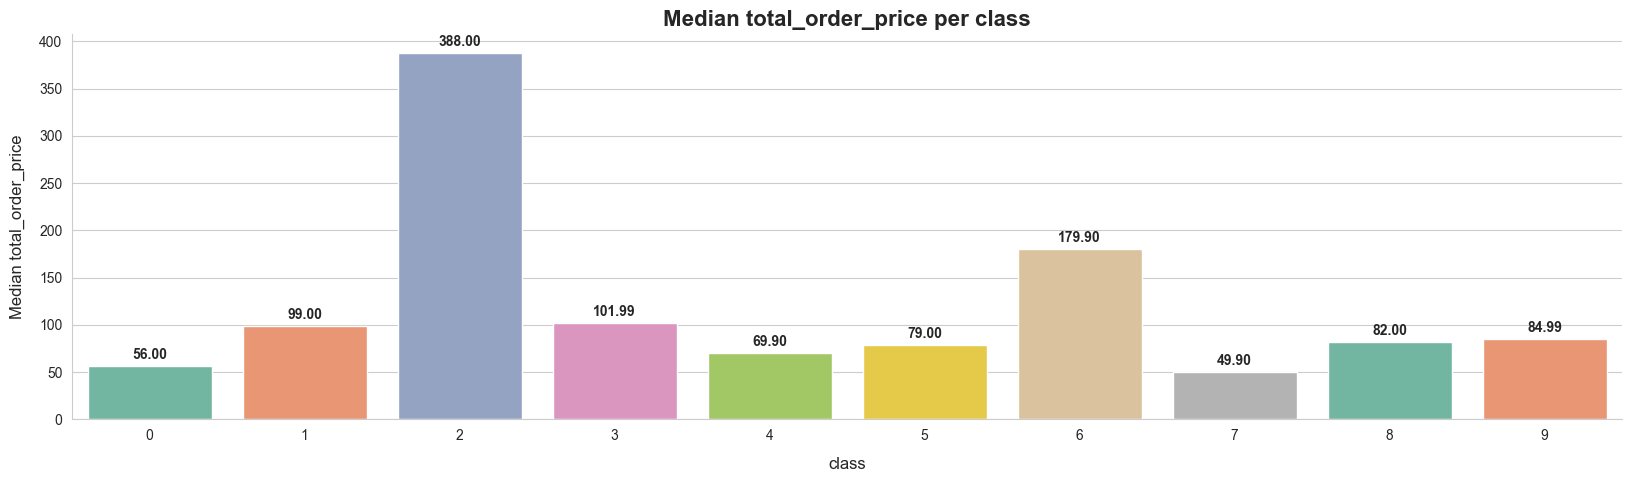

In [84]:
order_price_per_class=data.groupby('class')['total_order_price'].median().reset_index()
plot_median_bar(order_price_per_class,'class','total_order_price',figsize=(20,5))

### ` Class 3 have the highest median order value`

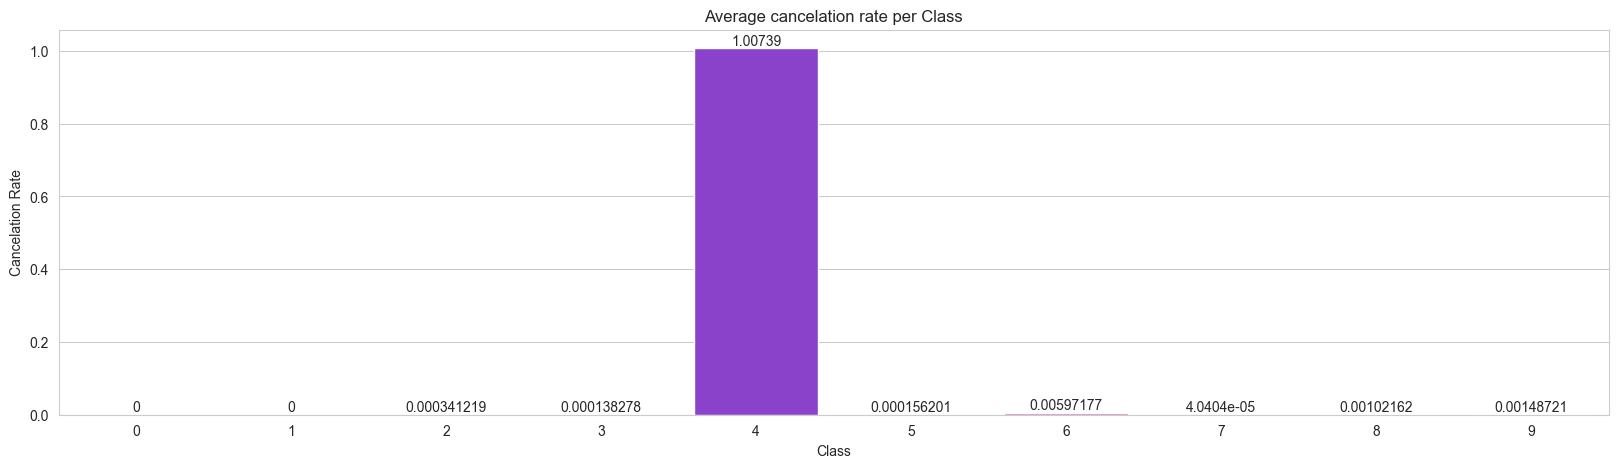

In [85]:
cancel_rate_per_class=data.groupby('class')['cancel_rate'].mean().reset_index()
plt.figure(figsize=(20,5))
ax=sns.barplot(x='class',y='cancel_rate',data=cancel_rate_per_class,palette='bright')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Average cancelation rate per Class')
plt.xlabel('Class')
plt.ylabel('Cancelation Rate')
plt.show()

### ` Class 4 have the highest cancelation rate`

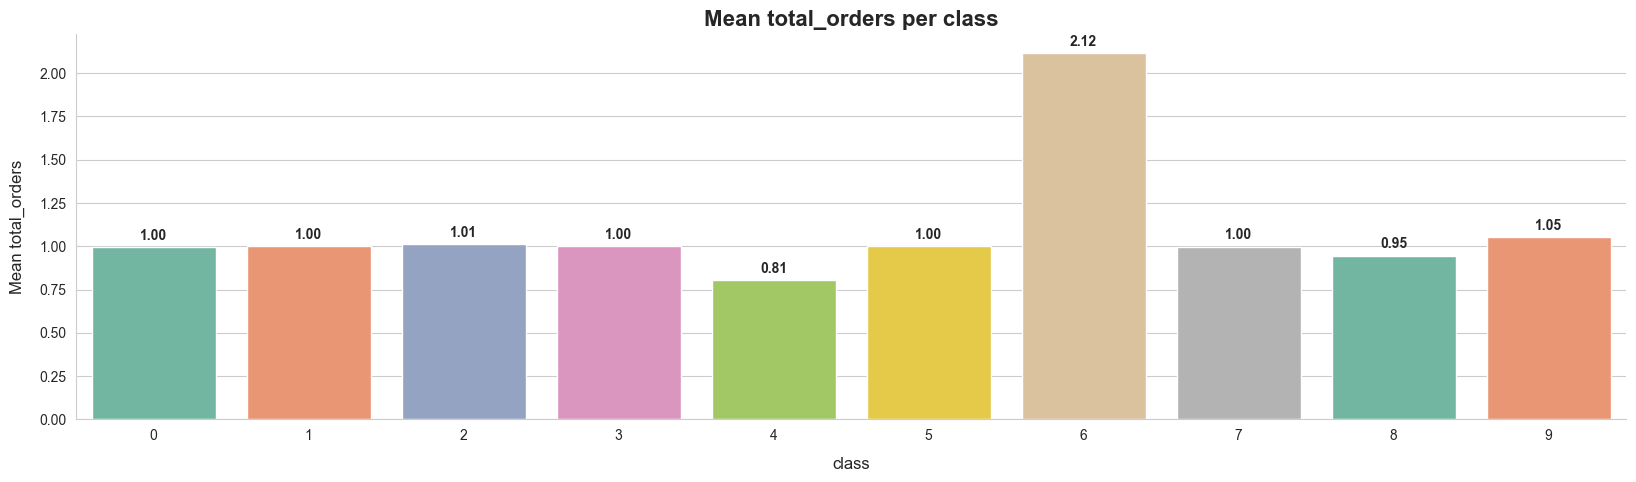

In [86]:
total_orders_per_class=data.groupby('class')['total_orders'].mean().reset_index()
plot_mean_bar(total_orders_per_class,'class','total_orders',figsize=(20,5))

### `Class 6 have the most average order`

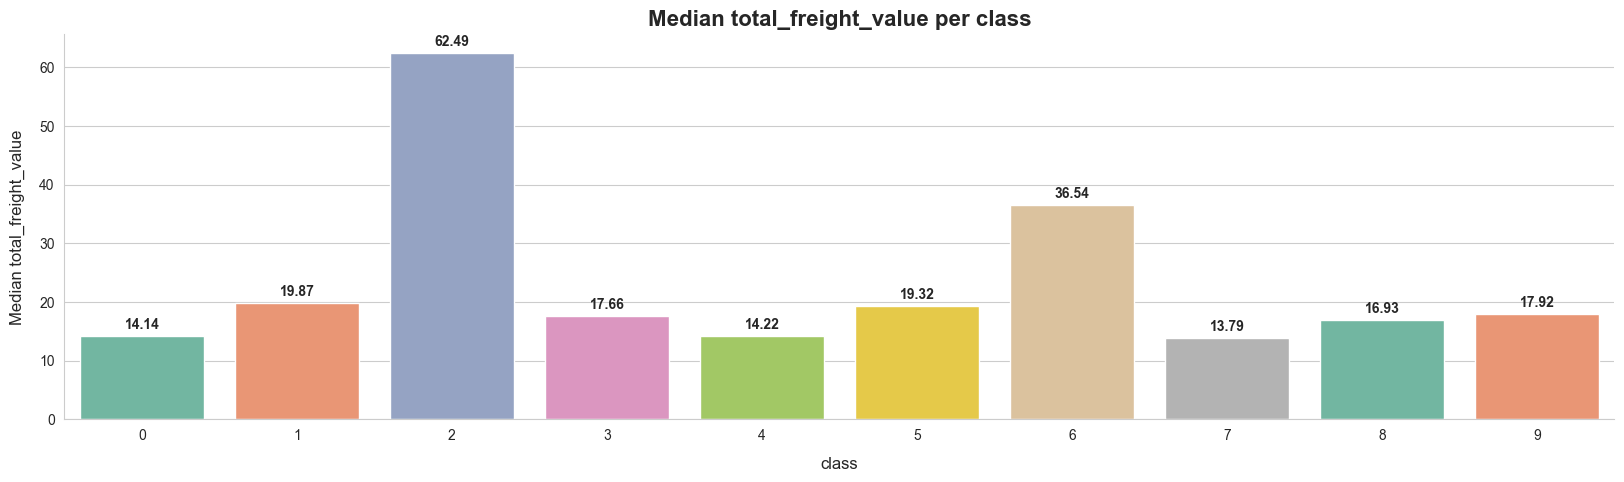

In [91]:
freight_value_per_class=data.groupby('class')['total_freight_value'].median().reset_index()
plot_median_bar(freight_value_per_class,'class','total_freight_value',figsize=(20,5))

### `Class 2 have the highest median freight value`

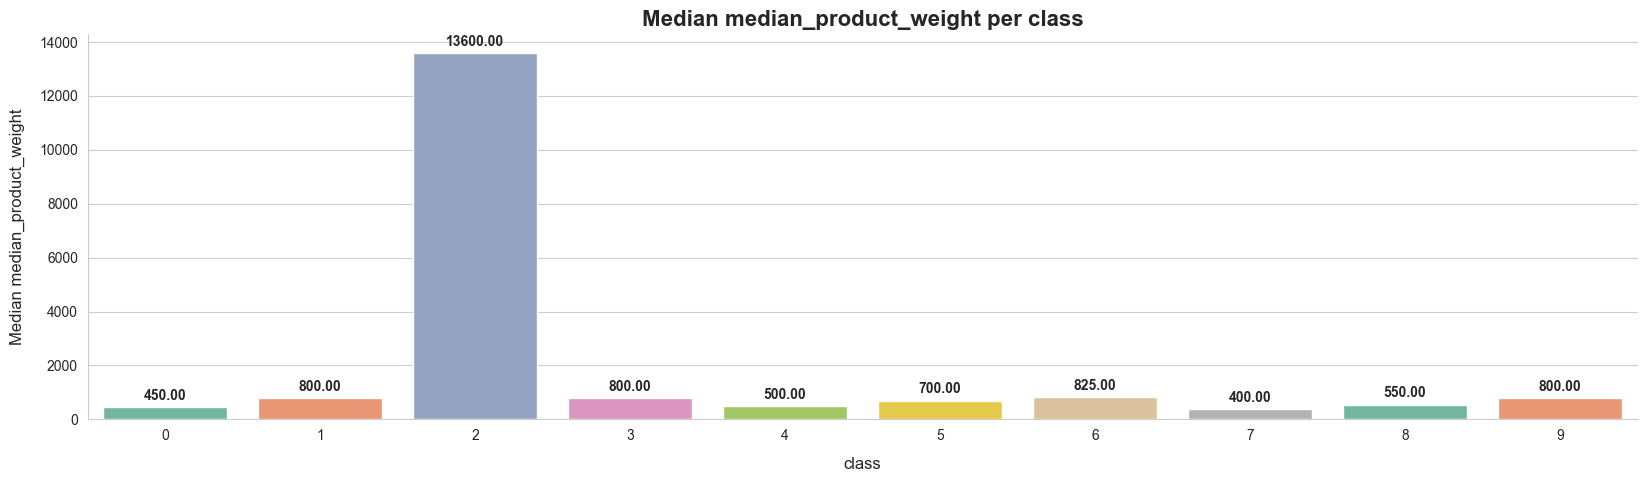

In [94]:
mean_product_weight_per_class=data.groupby('class')['median_product_weight'].median().reset_index()
plot_median_bar(mean_product_weight_per_class,'class','median_product_weight',figsize=(20,5))

### `Class 2 have the highest average of median product weight`

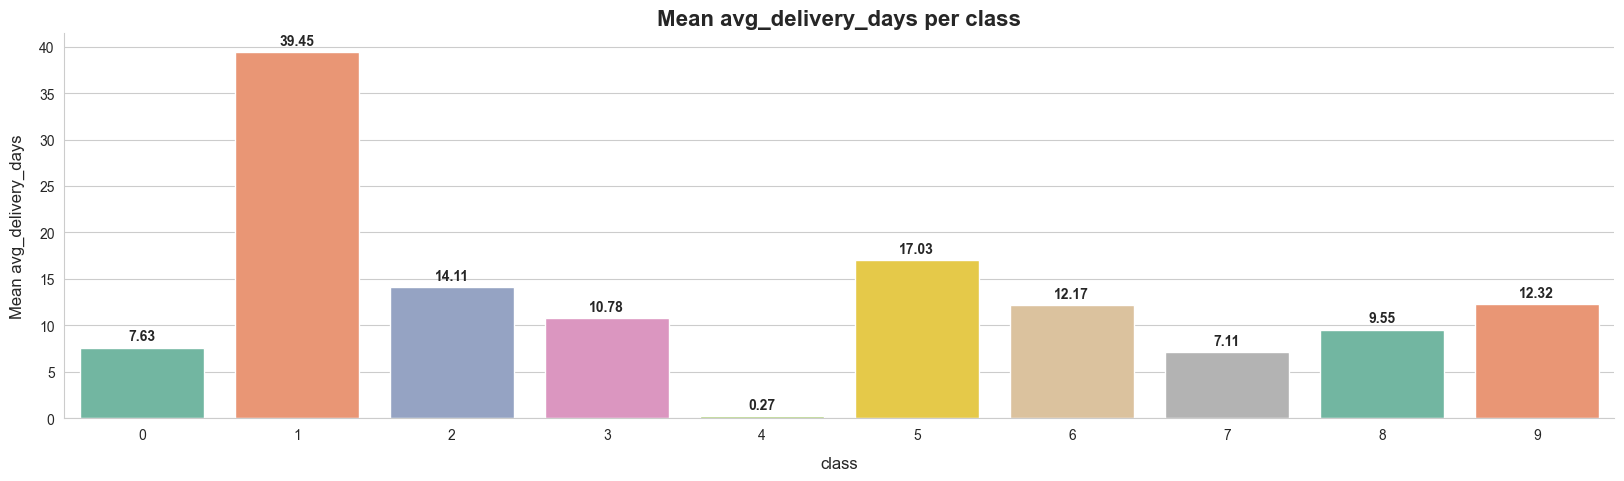

In [98]:
average_delivery_days_per_class=data.groupby('class')['avg_delivery_days'].mean().reset_index()
plot_mean_bar(average_delivery_days_per_class,'class','avg_delivery_days',figsize=(20,5))

### `Class 1 have the highest average delivery days`

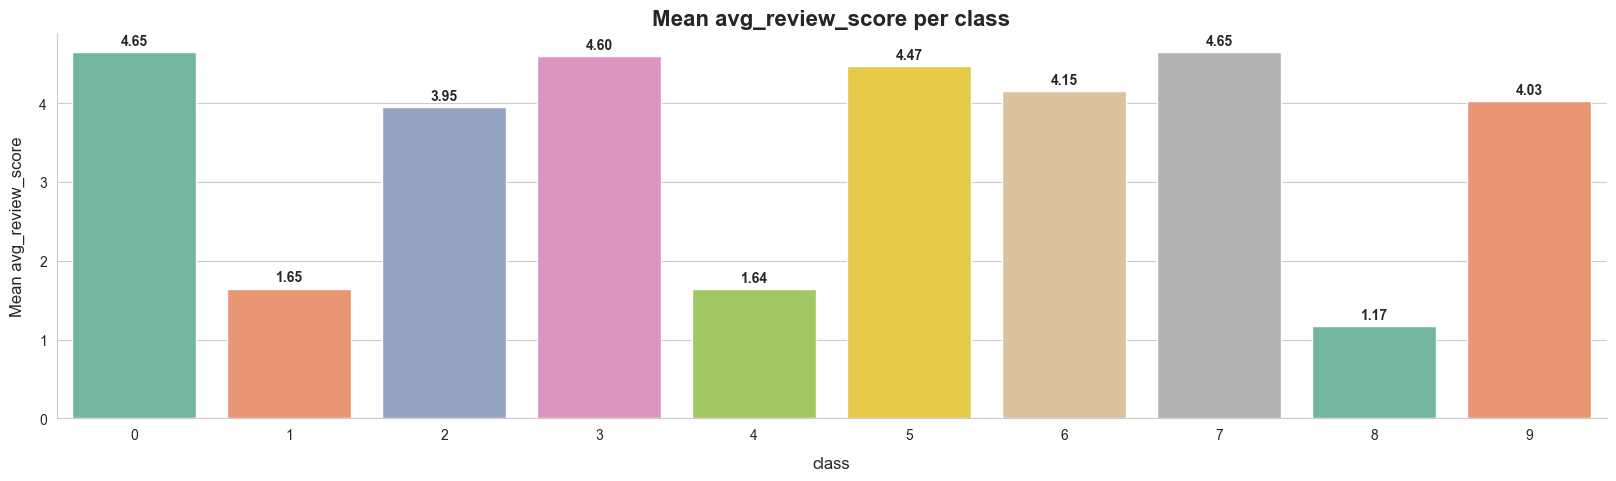

In [99]:
average_delivery_days_per_class=data.groupby('class')['avg_review_score'].mean().reset_index()
plot_mean_bar(average_delivery_days_per_class,'class','avg_review_score',figsize=(20,5))

### `Class 1,4,8 gives the lowest review`

In [103]:
data.groupby('class')['customer_state'].value_counts().groupby(level=0).head(1)

class  customer_state
0      SP                 7729
1      RJ                 1206
2      SP                 1523
3      SP                14782
4      SP                  283
5      RJ                 2096
6      SP                 1195
7      SP                 8118
8      SP                 4158
9      SP                  688
Name: count, dtype: int64

### `Class 1 and 5 customers are most from RJ state, others are from SP most`

In [104]:
data.groupby('class')['fav_payment_mode'].value_counts().groupby(level=0).head(1)

class  fav_payment_mode
0      boleto               6735
1      credit_card          3655
2      credit_card          3557
3      credit_card         36158
4      credit_card           396
5      boleto               7008
6      credit_card          2079
7      credit_card         10743
8      credit_card          7128
9      voucher              1417
Name: count, dtype: int64

### `Class 1 and 5 customers have boleto as most used payment type and 9 uses voucher`

In [110]:
fav_seller_id_with_count=data.groupby('class')['fav_seller_id'].value_counts().groupby(level=0).head(1).reset_index()
fav_seller_id_with_count

,class,fav_seller_id,count
0,0,6560211a19b47992c3666cc44a7e94c0,245
1,1,4a3ca9315b744ce9f8e9374361493884,118
2,2,7c67e1448b00f6e969d365cea6b010ab,377
3,3,4a3ca9315b744ce9f8e9374361493884,793
4,4,undefined,105
5,5,1f50f920176fa81dab994f9023523100,358
6,6,4a3ca9315b744ce9f8e9374361493884,87
7,7,8b321bb669392f5163d04c59e235e066,278
8,8,undefined,498
9,9,4a3ca9315b744ce9f8e9374361493884,42


### `Class 4 and 8 customers have mostly undefined seller id`

In [112]:
fav_seller_id_with_count=data.groupby('class')['fav_seller_id'].value_counts().groupby(level=0).head(1).reset_index()
fav_seller_id_with_count.groupby('fav_seller_id').size().reset_index()

,fav_seller_id,0
0,1f50f920176fa81dab994f9023523100,1
1,4a3ca9315b744ce9f8e9374361493884,4
2,6560211a19b47992c3666cc44a7e94c0,1
3,7c67e1448b00f6e969d365cea6b010ab,1
4,8b321bb669392f5163d04c59e235e066,1
5,undefined,2


### `There is one seller id which is favourite for 4 classes`

In [113]:
data.groupby('class')['seller_state'].value_counts().groupby(level=0).head(1)

class  seller_state
0      SP               8754
1      SP               3343
2      SP               2820
3      SP              24946
4      SP                312
5      SP               8334
6      SP               1678
7      SP               9390
8      SP               6500
9      SP               1194
Name: count, dtype: int64

In [114]:
data.groupby('class')['fav_product_category'].value_counts().groupby(level=0).head(1)

class  fav_product_category 
0      health_beauty            1109
1      bed_bath_table            481
2      office_furniture          534
3      bed_bath_table           4153
4      undefined                 120
5      computers_accessories    1302
6      bed_bath_table            533
7      sports_leisure           1243
8      bed_bath_table           1010
9      bed_bath_table            210
Name: count, dtype: int64

### `Class 4 have mostly undefined product category`

In [115]:
data.groupby('class')['fav_purchase_time'].value_counts().groupby(level=0).head(1)

class  fav_purchase_time
0      evening              6351
1      afternoon            1145
2      afternoon            1184
3      afternoon            9181
4      afternoon             146
5      afternoon            3495
6      afternoon            1051
7      night                5128
8      afternoon            2425
9      evening               441
Name: count, dtype: int64

### `Class 7 prefers to mostly order at night`

In [117]:
data.groupby('class')['payemnt_installments'].value_counts().groupby(level=0).head(1)

class  payemnt_installments
0      0                       11557
1      1                        2811
2      1                        3172
3      1                       36159
4      1                         272
5      0                       12804
6      1                        1796
7      0                       12375
8      1                        4888
9      0                        1545
Name: count, dtype: int64

In [118]:
data.groupby('class')['sequential_payment'].value_counts().groupby(level=0).head(1)

class  sequential_payment
0      0                     11557
1      0                      4520
2      0                      4391
3      0                     36159
4      0                       534
5      0                     12804
6      0                      2748
7      0                     12375
8      0                      9299
9      1                      1681
Name: count, dtype: int64

### `Class 9 customers mostly uses sequential payments`

🔑 Key Insights from Customer Segmentation

High-value vs High-volume customers

Class 3 spends the most per order (highest median order value).

Class 6 places the most orders (volume-driven).
→ Clear divide: some customers buy fewer but high-value orders, others buy frequent but lower-value orders.

Risky customer segments

Class 4 shows the highest cancellation rate + undefined sellers/products → risky/unreliable segment.

Class 1 has longest delivery days and lowest reviews → poor experience.
→ These classes highlight areas to improve logistics, seller quality, and service.

Logistics & cost drivers

Class 2 leads in freight value and product weight → heavy orders, higher delivery cost.

These customers are costly to serve, but also profitable if managed well.

Geographic concentration

Class 1 & 5 → mostly in RJ state.

Other classes → concentrated in SP state.
→ Regional strategies might work better (RJ vs SP focused).

Payment behavior

Class 1 & 5 → prefer boleto (traditional).

Class 9 → uses voucher and sequential payments (tech-savvy, price-sensitive).
→ Clear generational / digital divide in customer behavior.

Behavioral differences

Class 7 prefers night orders → lifestyle-driven pattern.

Class 4 & 8 → low reviews, cancellations, undefined sellers → least loyal customers.